In [1]:
from google.colab import files
uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [2]:
import zipfile

zip_path = "/content/dataset.zip"   # your uploaded file
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("done")

done


In [3]:
import os
os.listdir("/content")

['.config', 'dataset', 'Forest (6).jpg', 'dataset.zip', 'sample_data']

In [4]:
os.listdir("/content/dataset")

['test', 'train', 'val']

In [5]:
data_dir = "/content/dataset"

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

In [7]:
data_dir = "/content/dataset"

img_size = (224, 224)
batch_size = 32

train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    f"{data_dir}/train",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    f"{data_dir}/val",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 204 images belonging to 6 classes.
Found 44 images belonging to 6 classes.


In [8]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [9]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.4853 - loss: 1.5175 - val_accuracy: 0.5909 - val_loss: 0.9730
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.8137 - loss: 0.4273 - val_accuracy: 0.6818 - val_loss: 0.6549
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9265 - loss: 0.2443 - val_accuracy: 0.7273 - val_loss: 0.5481
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9510 - loss: 0.1547 - val_accuracy: 0.7727 - val_loss: 0.5430
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9853 - loss: 0.1017 - val_accuracy: 0.7273 - val_loss: 0.5541


In [12]:
# Step 1: Generators (with augmentation)
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)

# Step 2: Reload data (IMPORTANT)
train_data = train_gen.flow_from_directory(
    f"{data_dir}/train",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    f"{data_dir}/val",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 204 images belonging to 6 classes.
Found 44 images belonging to 6 classes.


In [13]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9461 - loss: 0.1838 - val_accuracy: 0.7955 - val_loss: 0.5146
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.9363 - loss: 0.1957 - val_accuracy: 0.8409 - val_loss: 0.5053
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.9510 - loss: 0.1310 - val_accuracy: 0.7727 - val_loss: 0.5509
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.9706 - loss: 0.1132 - val_accuracy: 0.7727 - val_loss: 0.5728
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.9804 - loss: 0.0901 - val_accuracy: 0.8409 - val_loss: 0.5538


In [14]:
base_model.trainable = True

# Freeze most layers, unfreeze last few
for layer in base_model.layers[:-20]:
    layer.trainable = False

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=3
)

Epoch 1/3
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.7353 - loss: 0.8863 - val_accuracy: 0.8409 - val_loss: 0.5491
Epoch 2/3
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.7941 - loss: 0.7377 - val_accuracy: 0.8182 - val_loss: 0.5458
Epoch 3/3
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.8088 - loss: 0.5818 - val_accuracy: 0.8409 - val_loss: 0.5441


In [17]:
test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    f"{data_dir}/test",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 44 images belonging to 6 classes.


In [18]:
test_loss, test_acc = model.evaluate(test_data)

print("Test Accuracy:", test_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 396ms/step - accuracy: 0.8409 - loss: 0.3808
Test Accuracy: 0.8409090638160706


In [19]:
import numpy as np

preds = model.predict(test_data)
pred_classes = np.argmax(preds, axis=1)
true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step


In [20]:
from collections import Counter

print("Predicted class distribution:")
print(Counter(pred_classes))

Predicted class distribution:
Counter({np.int64(5): 11, np.int64(2): 8, np.int64(1): 7, np.int64(3): 7, np.int64(4): 6, np.int64(0): 5})


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

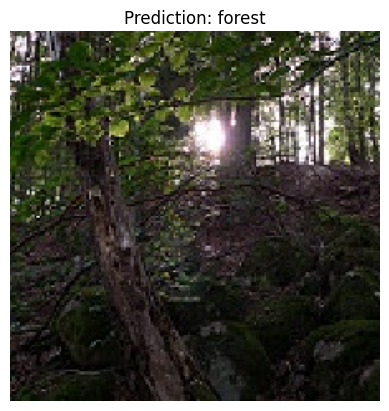

In [21]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img_path = "Forest (6).jpg"

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
pred_label = class_labels[np.argmax(prediction)]

plt.imshow(img)
plt.title(f"Prediction: {pred_label}")
plt.axis('off')

In [ ]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img_path = "Forest (6).jpg"

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
pred_label = class_labels[np.argmax(prediction)]

plt.imshow(img)
plt.title(f"Prediction: {pred_label}")
plt.axis('off')